In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


# Import BERT model and hook

In [37]:
from transformers import BertTokenizer, BertForMaskedLM, logging

logging.set_verbosity_error()

# Load BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-large-uncased')
model = BertForMaskedLM.from_pretrained('bert-large-uncased')

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval();

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

In [51]:
# indices (redefined later)
layer2replace = 40000 # no replacement...
hs_vector2replace = torch.zeros(model.config.hidden_size)


mixture = [.1,.9]

# hooking functions
def implant_hook(layer_number):
    def hook(module, input, output):

      if layer_number != layer2replace:
          return output

      if isinstance(output, tuple):
          hidden = output[0].clone()
          rest = output[1:]
      else:
          hidden = output.clone()
          rest = None

      hidden[0, maskTarget_idx, :] = (
          mixture[0] * hidden[0, maskTarget_idx, :] +
          mixture[1] * hs_vector2replace
      )

      if rest is None:
          return hidden
      else:
          return (hidden, *rest)

    return hook


# loop over layers and do surgery
handles = []
for layeri in range(model.config.num_hidden_layers):
  h = model.bert.encoder.layer[layeri].register_forward_hook(implant_hook(layeri))
  handles.append(h)

# Test for a gender bias in BERT

In [52]:
# list of target words
target_words = [ 'he','she','they' ]

# tokenize sentences
tokens_he   = tokenizer(f'The engineer informed the client that he would need more time.',return_tensors='pt')
tokens_she  = tokenizer(f'The engineer informed the client that she would need more time.',return_tensors='pt')
tokens_they = tokenizer(f'The engineer informed the client that they would need more time.',return_tensors='pt')

# tokenize the masked sentence
tokens_mask = tokenizer(f'The engineer informed the client that [MASK] would need more time.',return_tensors='pt')

In [53]:
# the mask index
maskTarget_idx = torch.where(tokens_mask['input_ids'][0] == tokenizer.mask_token_id)[0].item()

# token indices of target words
targets_idx = [tokenizer.encode(t)[1] for t in target_words]

# print out the tokens
for t in tokens_mask['input_ids'][0]:
  print(f'{t:5}: "{tokenizer.decode(t)}"')

print(f'\nThe mask is in token index {maskTarget_idx}\n')
for t in targets_idx:
  print(f'Target "{tokenizer.decode(t)}" is index {t}')

  101: "[CLS]"
 1996: "the"
 3992: "engineer"
 6727: "informed"
 1996: "the"
 7396: "client"
 2008: "that"
  103: "[MASK]"
 2052: "would"
 2342: "need"
 2062: "more"
 2051: "time"
 1012: "."
  102: "[SEP]"

The mask is in token index 7

Target "he" is index 2002
Target "she" is index 2016
Target "they" is index 2027


In [54]:
# redefine as outside the range, in case you want to rerun this code later
layer2replace = 40000

# forward-pass the four versions
with torch.no_grad():
  out_he = model(**tokens_he.to(device),output_hidden_states=True)
  out_she = model(**tokens_she.to(device),output_hidden_states=True)
  out_they = model(**tokens_they.to(device),output_hidden_states=True)
  out_mask = model(**tokens_mask.to(device),output_hidden_states=True)

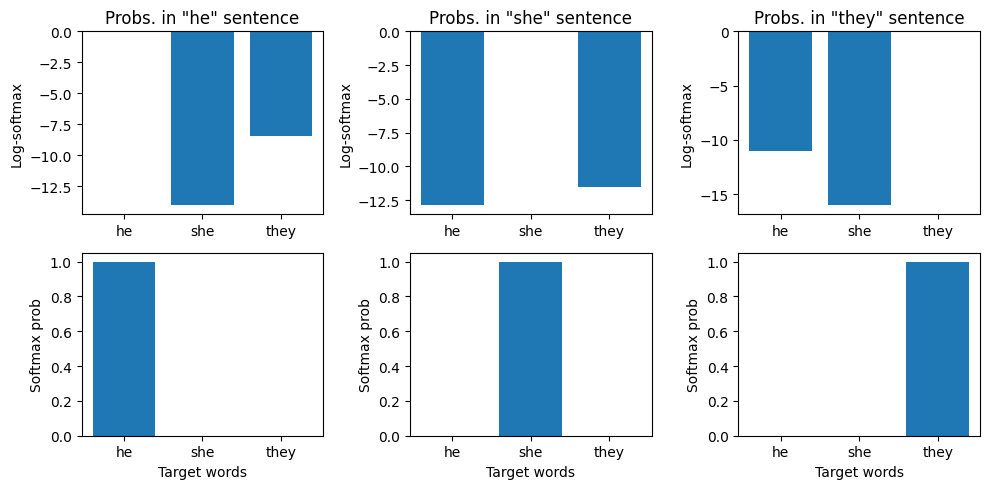

In [55]:
# grab and visualize the log-softmax

fig,axs = plt.subplots(2,3,figsize=(10,5))

# for "he"
logsm = F.log_softmax(out_he.logits[0,maskTarget_idx,:],dim=-1).detach().cpu()
axs[0,0].bar(range(3),logsm[targets_idx])
axs[1,0].bar(range(3),torch.exp(logsm[targets_idx]))
axs[0,0].set(xticks=range(3),xticklabels=target_words,ylabel='Log-softmax',title='Probs. in "he" sentence')
axs[1,0].set(xticks=range(3),xticklabels=target_words,xlabel='Target words',ylabel='Softmax prob')


# for "she"
logsm = F.log_softmax(out_she.logits[0,maskTarget_idx,:],dim=-1).detach().cpu()
axs[0,1].bar(range(3),logsm[targets_idx])
axs[1,1].bar(range(3),torch.exp(logsm[targets_idx]))
axs[0,1].set(xticks=range(3),xticklabels=target_words,ylabel='Log-softmax',title='Probs. in "she" sentence')
axs[1,1].set(xticks=range(3),xticklabels=target_words,xlabel='Target words',ylabel='Softmax prob')

# for "they"
logsm = F.log_softmax(out_they.logits[0,maskTarget_idx,:],dim=-1).detach().cpu()
axs[0,2].bar(range(3),logsm[targets_idx])
axs[1,2].bar(range(3),torch.exp(logsm[targets_idx]))
axs[0,2].set(xticks=range(3),xticklabels=target_words,ylabel='Log-softmax',title='Probs. in "they" sentence')
axs[1,2].set(xticks=range(3),xticklabels=target_words,xlabel='Target words',ylabel='Softmax prob')


plt.tight_layout()
plt.show()

In [ ]:
# grab and visualize the log-softmax
logsm = F.log_softmax(out_mask.logits[0,maskTarget_idx,:],dim=-1).detach().cpu()

fig,axs = plt.subplots(1,2,figsize=(10,3.5))

axs[0].bar(range(3),logsm[targets_idx])
axs[1].bar(range(3),torch.exp(logsm[targets_idx]))

axs[0].set(xticks=range(3),xticklabels=target_words,xlabel='Target words',ylabel='Log-softmax',title='Log-softmax for masked word')
axs[1].set(xticks=range(3),xticklabels=target_words,xlabel='Target words',ylabel='Softmax prob.',title='Softmax probability for masked word')

fig.suptitle(tokenizer.decode(tokens_mask['input_ids'][0,1:-1]),fontweight='bold')

plt.tight_layout()
plt.show()

# Manipulate the hidden state of the transformer for layer 10

In [46]:
layer2replace = 10
hs_vector2replace = out_she.hidden_states[layer2replace+1][0,maskTarget_idx,:] # 1 is added as the hidden state 0 for hf transformer models is the embedding layer
mixture = [.1,.9]

with torch.no_grad():
  out_mask_replace = model(**tokens_mask.to(device),output_hidden_states=True)

Replaced layer 10
Replaced layer 10


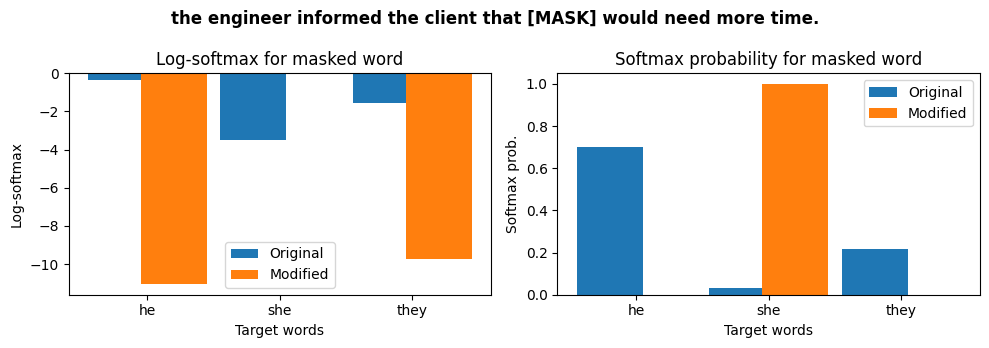

In [47]:
# grab and visualize the log-softmax
logsm_orig = F.log_softmax(out_mask.logits[0,maskTarget_idx,:],dim=-1).detach().cpu()
logsm_repl = F.log_softmax(out_mask_replace.logits[0,maskTarget_idx,:],dim=-1).detach().cpu()

fig,axs = plt.subplots(1,2,figsize=(10,3.5))

axs[0].bar(np.arange(3)-.2,logsm_orig[targets_idx],width=.5,label='Original')
axs[0].bar(np.arange(3)+.2,logsm_repl[targets_idx],width=.5,label='Modified')
axs[0].legend()
axs[0].set(xticks=range(3),xticklabels=target_words,xlabel='Target words',ylabel='Log-softmax',title='Log-softmax for masked word')

axs[1].bar(np.arange(3)-.2,torch.exp(logsm_orig[targets_idx]),width=.5,label='Original')
axs[1].bar(np.arange(3)+.2,torch.exp(logsm_repl[targets_idx]),width=.5,label='Modified')
axs[1].legend()
axs[1].set(xticks=range(3),xticklabels=target_words,xlabel='Target words',ylabel='Softmax prob.',title='Softmax probability for masked word')

fig.suptitle(tokenizer.decode(tokens_mask['input_ids'][0,1:-1]),fontweight='bold')

plt.tight_layout()
plt.show()

In [48]:
bias_orig = logsm_orig[targets_idx[0]] - logsm_orig[targets_idx[1]]
bias_repl = logsm_repl[targets_idx[0]] - logsm_repl[targets_idx[1]]

print(f'Bias (he-she) in original model: {bias_orig:.3f}')
print(f'Bias (he-she) in modified model: {bias_repl:.3f}')

Bias (he-she) in original model: 3.160
Bias (he-she) in modified model: -11.053


# Run for all layers

In [49]:
targets_idx

[2002, 2016, 2027]

In [50]:
biases = torch.zeros(model.config.num_hidden_layers)

mixture = [.5,.5]

for layeri in range(model.config.num_hidden_layers):
  layer2replace = layeri
  hs_vector2replace = out_she.hidden_states[layer2replace+1][0,maskTarget_idx,:]

  with torch.no_grad():
    out_mask_replace = model(**tokens_mask.to(device),output_hidden_states=True)

  logsm_repl = F.log_softmax(out_mask_replace.logits[0,maskTarget_idx,:],dim=-1).detach().cpu()
  bias_repl = logsm_repl[targets_idx[0]] - logsm_repl[targets_idx[1]]

  biases[layeri] = bias_repl

Replaced layer 0
Replaced layer 0
Replaced layer 1
Replaced layer 1
Replaced layer 2
Replaced layer 2
Replaced layer 3
Replaced layer 3
Replaced layer 4
Replaced layer 4
Replaced layer 5
Replaced layer 5
Replaced layer 6
Replaced layer 6
Replaced layer 7
Replaced layer 7
Replaced layer 8
Replaced layer 8
Replaced layer 9
Replaced layer 9
Replaced layer 10
Replaced layer 10
Replaced layer 11
Replaced layer 11
Replaced layer 12
Replaced layer 12
Replaced layer 13
Replaced layer 13
Replaced layer 14
Replaced layer 14
Replaced layer 15
Replaced layer 15
Replaced layer 16
Replaced layer 16
Replaced layer 17
Replaced layer 17
Replaced layer 18
Replaced layer 18
Replaced layer 19
Replaced layer 19
Replaced layer 20
Replaced layer 20
Replaced layer 21
Replaced layer 21
Replaced layer 22
Replaced layer 22
Replaced layer 23
Replaced layer 23


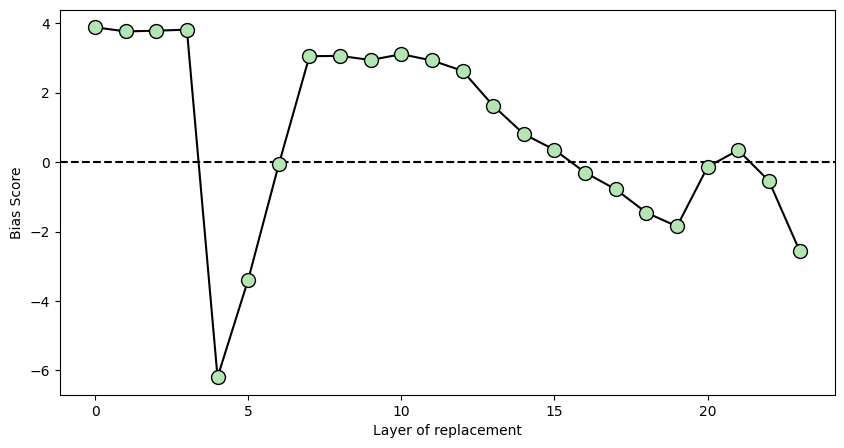

In [24]:
# Visualize
plt.figure(figsize=(10,5))
plt.plot(range(model.config.num_hidden_layers),biases, 'ko-', mfc=[.7,.9,.7,1], ms=10)
plt.axhline(0,linestyle='--',color='k', zorder=-10)
plt.xlabel('Layer of replacement')
plt.ylabel('Bias Score')

plt.show()

In [36]:
for h in handles:
  h.remove()